# Naive Bayes Sentiment Classifier - Course Reviews

**Dataset:** `user_courses_review_09_2023.csv`
**Author:** Waheed

Goal: train a **Naive Bayes** classifier to label review text as **good (positive)** or
**bad (negative)**, and attempt a direct **1-5 star** classifier.

Our EDA flagged the central obstacle: the data is **~99% positive (only ~119 negative
reviews)**. This notebook shows how that imbalance makes plain *accuracy* misleading, and how
an imbalance-aware model changes the picture.

## 1. Load & prepare text

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("user_courses_review_09_2023.csv", engine="python", on_bad_lines="skip")
df["review_rating"] = pd.to_numeric(df["review_rating"], errors="coerce")
df = df[df["review_rating"].isin([1,2,3,4,5])].copy()
df["review_rating"] = df["review_rating"].astype(int)
df["comment"] = df["review_comment"].fillna("").astype(str)
df = df[df["comment"].str.strip().str.len() > 0]        # need text to classify
print(f"{len(df):,} reviews with text")

10,604 reviews with text


## 2. Binary target + TF-IDF features

Positive = 4-5 stars, Negative = 1-2 stars, neutral (3) dropped. We convert text to numbers
with **TF-IDF** (tokenisation + weighted vectorisation in one step) using unigrams + bigrams,
and hold out 25% for testing with a **stratified** split so the rare negatives appear in both
sets.

In [2]:
b = df[df["review_rating"] != 3].copy()
b["y"] = (b["review_rating"] >= 4).astype(int)          # 1 = positive, 0 = negative

Xtr, Xte, ytr, yte = train_test_split(b["comment"], b["y"], test_size=0.25,
                                      stratify=b["y"], random_state=42)
vec = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2)
Xtr_v = vec.fit_transform(Xtr); Xte_v = vec.transform(Xte)
print(f"train={Xtr.shape[0]}  test={Xte.shape[0]}  |  negatives in test set: {int((yte==0).sum())}")
print(f"features (vocabulary size): {len(vec.get_feature_names_out()):,}")

train=7770  test=2591  |  negatives in test set: 29
features (vocabulary size): 3,748


## 3. Baseline: `MultinomialNB` - and the accuracy trap

Accuracy: 0.989
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        29
    positive       0.99      1.00      0.99      2562

    accuracy                           0.99      2591
   macro avg       0.49      0.50      0.50      2591
weighted avg       0.98      0.99      0.98      2591



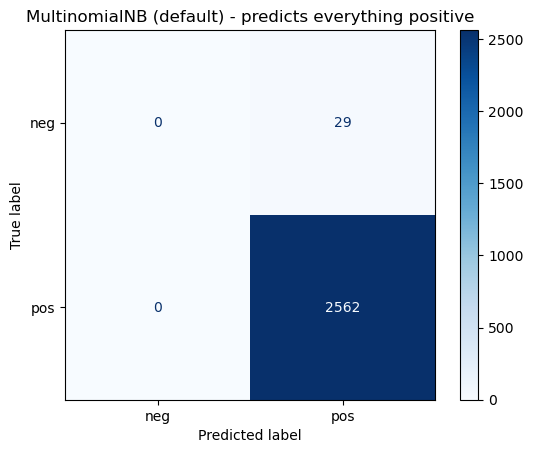

In [3]:
nb0 = MultinomialNB().fit(Xtr_v, ytr)
pred0 = nb0.predict(Xte_v)
print(f"Accuracy: {(pred0==yte).mean():.3f}")
print(classification_report(yte, pred0, target_names=["negative","positive"], zero_division=0))
ConfusionMatrixDisplay(confusion_matrix(yte, pred0), display_labels=["neg","pos"]).plot(cmap="Blues")
plt.title("MultinomialNB (default) - predicts everything positive"); plt.show()

**Interpretation - why 98.9% accuracy is a lie.**
The default model scores **~98.9% accuracy** - but its **negative recall is 0.00**. The
confusion matrix shows it labels *every* test review positive, catching **none** of the 29
negatives. Because positives are ~99% of the data, "always predict positive" is automatically
~99% accurate and completely useless for finding unhappy customers. This is exactly why we
insisted on precision/recall per class rather than accuracy.

## 4. Imbalance-aware: `ComplementNB`

`ComplementNB` is a Naive Bayes variant **designed for imbalanced text** - it estimates each
class from the *complement* of the other, so the tiny negative class is no longer drowned out.

Accuracy: 0.922


              precision    recall  f1-score   support

    negative       0.06      0.41      0.11        29
    positive       0.99      0.93      0.96      2562

    accuracy                           0.92      2591
   macro avg       0.53      0.67      0.53      2591
weighted avg       0.98      0.92      0.95      2591



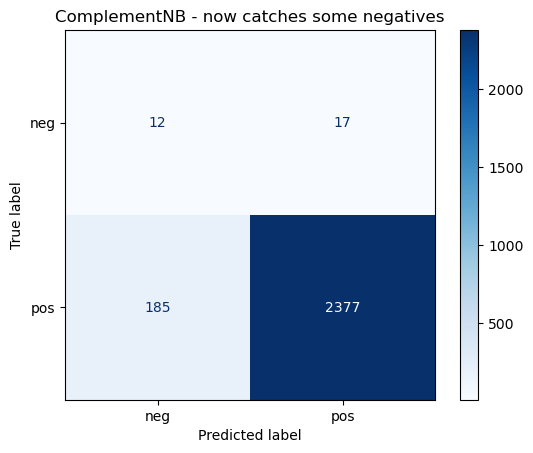

In [4]:
nb1 = ComplementNB().fit(Xtr_v, ytr)
pred1 = nb1.predict(Xte_v)
print(f"Accuracy: {(pred1==yte).mean():.3f}")
print(classification_report(yte, pred1, target_names=["negative","positive"], zero_division=0))
ConfusionMatrixDisplay(confusion_matrix(yte, pred1), display_labels=["neg","pos"]).plot(cmap="Blues")
plt.title("ComplementNB - now catches some negatives"); plt.show()

**Interpretation - a real trade-off.**
Accuracy *drops* to ~92%, but **negative recall rises from 0.00 to ~0.41** - the model now
catches roughly 4 in 10 negative reviews instead of none. The cost is low **negative precision
(~0.06)**: to find those negatives it also mislabels many positives as negative. That trade-off
(catch more complaints, but with more false alarms) is the crux of imbalanced classification -
and a lower "accuracy" here is the *better* model for the business goal of surfacing unhappy
reviewers.

## 5. Try it on new reviews

In [5]:
examples = [
    "This course was amazing and easy to understand!",
    "The pace was too fast and the content is outdated",
    "Waste of time, poorly explained",
    "Great instructor, learned a lot",
    "not what I expected, needs more examples",
]
for t in examples:
    label = "POSITIVE" if nb1.predict(vec.transform([t]))[0] == 1 else "NEGATIVE"
    print(f"{label:8s} <- {t}")

POSITIVE <- This course was amazing and easy to understand!
NEGATIVE <- The pace was too fast and the content is outdated
NEGATIVE <- Waste of time, poorly explained
POSITIVE <- Great instructor, learned a lot
POSITIVE <- not what I expected, needs more examples


**Interpretation.** The classifier handles clear cases well - it flags *"too fast and
outdated"* and *"poorly explained"* as negative (the very themes our regex analysis surfaced)
and praise as positive. Subtle, mixed reviews like *"needs more examples"* still slip through
as positive - consistent with the ~41% negative recall. Good enough to triage obvious
complaints, not to catch every nuance.

## 6. Stretch goal: direct 1-5 star classification

In [6]:
Xtr, Xte, ytr, yte = train_test_split(df["comment"], df["review_rating"], test_size=0.25,
                                      stratify=df["review_rating"], random_state=42)
vec5 = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2)
Xtr_v = vec5.fit_transform(Xtr); Xte_v = vec5.transform(Xte)

print("=== MultinomialNB (default) ===")
p_a = MultinomialNB().fit(Xtr_v, ytr).predict(Xte_v)
print(f"accuracy {(p_a==yte).mean():.3f}")
print(classification_report(yte, p_a, zero_division=0))

print("=== ComplementNB ===")
p_b = ComplementNB().fit(Xtr_v, ytr).predict(Xte_v)
print(f"accuracy {(p_b==yte).mean():.3f}")
print(classification_report(yte, p_b, zero_division=0))

=== MultinomialNB (default) ===
accuracy 0.894
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00        18
           3       0.00      0.00      0.00        61
           4       0.00      0.00      0.00       189
           5       0.89      1.00      0.94      2372

    accuracy                           0.89      2651
   macro avg       0.18      0.20      0.19      2651
weighted avg       0.80      0.89      0.84      2651

=== ComplementNB ===
accuracy 0.793
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        11
           2       0.05      0.06      0.05        18
           3       0.15      0.36      0.21        61
           4       0.20      0.21      0.21       189
           5       0.95      0.86      0.90      2372

    accuracy                           0.79      2651
   macro avg       0.27      0.30      0.27     

**Interpretation - why 1-5 doesn't really work here.**
Direct 5-class prediction runs into the same wall, harder. Default `MultinomialNB` reaches ~89%
accuracy but **only ever predicts 5 stars** (recall 0 for classes 1-4). `ComplementNB` spreads
its predictions across classes (macro-F1 ~0.27) but is weak on the sparse low ratings - classes
1 and 2 have only ~48 and ~71 examples in the whole dataset, far too few to learn. **Conclusion:
binary good/bad is the realistic target; 1-5 needs far more low-star data to be viable.**

## Summary & how to improve

- **TF-IDF + Naive Bayes** builds a working sentiment classifier from raw review text.
- **Accuracy is misleading under imbalance:** the default model hit 98.9% while catching *zero*
  negatives. Precision/recall per class and the confusion matrix tell the real story.
- **`ComplementNB`** trades overall accuracy for usable **negative recall (~0.41)** - the right
  call for surfacing unhappy reviewers.
- **1-5 classification is not viable** with only ~48-71 examples in the lowest classes.

**To improve:** collect far more negative/low-star reviews, or apply resampling (e.g. SMOTE /
under-sampling the positives), tune the decision threshold on predicted probabilities, or add
engineered features (review length, the regex complaint flags) alongside the text.

<!-- IMBALANCE-EXT -->
# Part 2 - Model variants & handling the imbalance

Two follow-ups: (a) compare the Naive Bayes *variants* (Multinomial vs Bernoulli vs
Complement), and (b) tackle the class imbalance with **resampling**.

<!-- IMBALANCE-EXT -->
## 7. Multinomial vs Bernoulli vs Complement NB

- **Multinomial** uses word **counts** (how often a word appears).
- **Bernoulli** uses **binary presence/absence** (did the word appear at all) and also models
  word *absence*.
- **Complement** is a Multinomial variant built for **imbalanced** text.

We judge them on the **negative class** (the hard one), each with its natural representation.

In [7]:
# IMBALANCE-EXT
from sklearn.naive_bayes import BernoulliNB
from sklearn.feature_extraction.text import CountVectorizer

bb = df[df["review_rating"] != 3].copy()
bb["y"] = (bb["review_rating"] >= 4).astype(int)
Xtr, Xte, ytr, yte = train_test_split(bb["comment"], bb["y"], test_size=0.25,
                                      stratify=bb["y"], random_state=42)

cnt  = CountVectorizer(stop_words="english", ngram_range=(1,2), min_df=2)
binv = CountVectorizer(stop_words="english", ngram_range=(1,2), min_df=2, binary=True)
tfi  = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2)
Xtr_c, Xte_c = cnt.fit_transform(Xtr),  cnt.transform(Xte)
Xtr_b, Xte_b = binv.fit_transform(Xtr), binv.transform(Xte)
Xtr_t, Xte_t = tfi.fit_transform(Xtr),  tfi.transform(Xte)

def report_neg(name, model, Xt, yt, Xe):
    model.fit(Xt, yt); pr = model.predict(Xe)
    r = classification_report(yte, pr, output_dict=True, zero_division=0)["0"]
    print(f"{name:26s} acc={(pr==yte).mean():.3f}  NEG precision={r['precision']:.2f} "
          f"recall={r['recall']:.2f} f1={r['f1-score']:.2f}")

report_neg("MultinomialNB (counts)", MultinomialNB(), Xtr_c, ytr, Xte_c)
report_neg("BernoulliNB (binary)",   BernoulliNB(),   Xtr_b, ytr, Xte_b)
report_neg("ComplementNB (tfidf)",   ComplementNB(),  Xtr_t, ytr, Xte_t)

MultinomialNB (counts)     acc=0.990  NEG precision=0.60 recall=0.21 f1=0.31
BernoulliNB (binary)       acc=0.985  NEG precision=0.00 recall=0.00 f1=0.00
ComplementNB (tfidf)       acc=0.922  NEG precision=0.06 recall=0.41 f1=0.11


<!-- IMBALANCE-EXT -->
**Interpretation - Multinomial wins here.**
**BernoulliNB fails** (negative F1 = 0.00): it labels everything positive. The reviews are so
short that word counts are already mostly 0/1, so Bernoulli's presence/absence view adds little,
and its explicit modelling of the many *absent* words just reinforces the 99% positive prior.
**MultinomialNB on counts is the best-balanced** (F1 = 0.31), while ComplementNB trades precision
for higher recall. Takeaway: for short, imbalanced review text, prefer **Multinomial over
Bernoulli** - the variant matters less than the imbalance itself.

<!-- IMBALANCE-EXT -->
## 8. Resampling to balance the classes

**Method rule:** we resample the **training set only** and evaluate on the **untouched test set**,
which keeps the real ~99/1 ratio. (Balancing the test set would inflate the metrics and hide the
model's true real-world behaviour.)

                      accuracy  neg_precision  neg_recall  neg_f1
method                                                           
No resampling            0.990          0.600       0.207   0.308
Undersample majority     0.674          0.032       0.966   0.062
Oversample minority      0.930          0.096       0.621   0.166
SMOTE (synthetic)        0.929          0.071       0.448   0.123


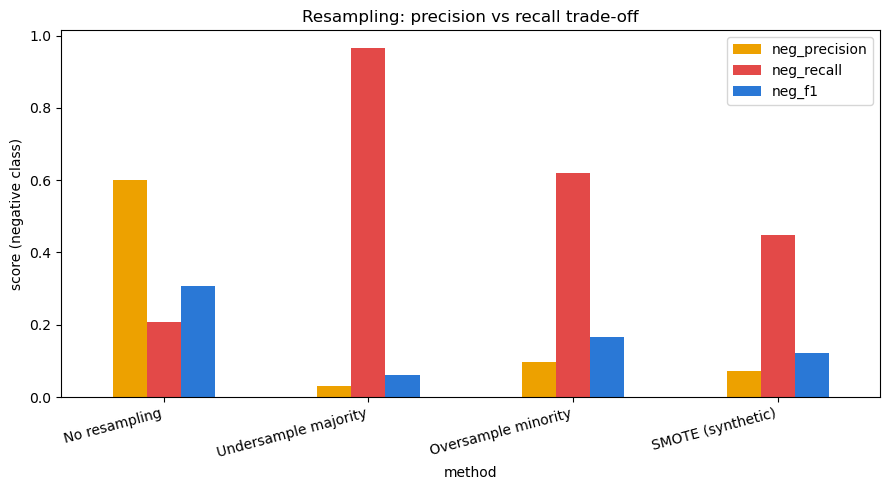

In [8]:
# IMBALANCE-EXT
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

samplers = {
    "No resampling":        None,
    "Undersample majority": RandomUnderSampler(random_state=42),
    "Oversample minority":  RandomOverSampler(random_state=42),
    "SMOTE (synthetic)":    SMOTE(random_state=42, k_neighbors=5),
}
results = []
for name, samp in samplers.items():
    Xr, yr = (Xtr_c, ytr) if samp is None else samp.fit_resample(Xtr_c, ytr)
    model = MultinomialNB().fit(Xr, yr)
    pr = model.predict(Xte_c)
    r = classification_report(yte, pr, output_dict=True, zero_division=0)["0"]
    results.append({"method": name, "accuracy": (pr==yte).mean(),
                    "neg_precision": r["precision"], "neg_recall": r["recall"], "neg_f1": r["f1-score"]})
res = pd.DataFrame(results).set_index("method").round(3)
print(res.to_string())

ax = res[["neg_precision", "neg_recall", "neg_f1"]].plot(kind="bar", figsize=(9,5),
        color=["#eda100", "#e34948", "#2a78d6"])
ax.set_ylabel("score (negative class)"); ax.set_title("Resampling: precision vs recall trade-off")
plt.xticks(rotation=15, ha="right"); plt.tight_layout(); plt.show()

<!-- IMBALANCE-EXT -->
**Interpretation - resampling shifts the trade-off, it doesn't create signal.**
Balancing the classes does **not** raise overall accuracy - it *falls* in every case - because
what resampling really does is make the model stop ignoring the minority, trading **precision for
recall**:
- **Undersampling** reaches ~0.97 negative recall but ~0.03 precision (it labels almost everything
  negative) and accuracy crashes to ~0.67 - too blunt.
- **Oversampling** is the sensible middle ground: recall ~0.62 while accuracy stays ~0.93.
- **No resampling** still holds the best F1 (~0.31) - the best precision/recall *balance*.

With only ~119 negatives in total, no resampling method can manufacture signal that isn't there;
it only redistributes attention. **Recommendation:** use **oversampling** if the goal is to catch
as many unhappy reviewers as possible, and accept lower precision - but the durable fix is
**collecting more negative reviews**.

<!-- REFRAME-EXT -->
# Part 3 - Improved framing: satisfied (4-5) vs not-satisfied (1-3)

So far "bad" meant 1-2 stars and we *dropped* the neutral 3s, leaving only ~119 negatives.
A better idea: treat **1-3 stars as "not satisfied"** and **4-5 as "satisfied"** (the NPS-style
split). This folds the ~250 three-star reviews into the minority class - adding **real** negative
examples rather than the synthetic copies that resampling produces. Real data beats synthetic, so
this should improve both the model *and* the reliability of our metrics.

<!-- REFRAME-EXT -->
## 9. Train the reframed model (1-3 = not-satisfied, 4-5 = satisfied)

'not satisfied' training examples: 270  (was 88 in the 1-2 framing)
'not satisfied' in test set:       90  (was 29 - now far more reliable)

Accuracy: 0.968
               precision    recall  f1-score   support

not satisfied       0.56      0.24      0.34        90
    satisfied       0.97      0.99      0.98      2561

     accuracy                           0.97      2651
    macro avg       0.77      0.62      0.66      2651
 weighted avg       0.96      0.97      0.96      2651



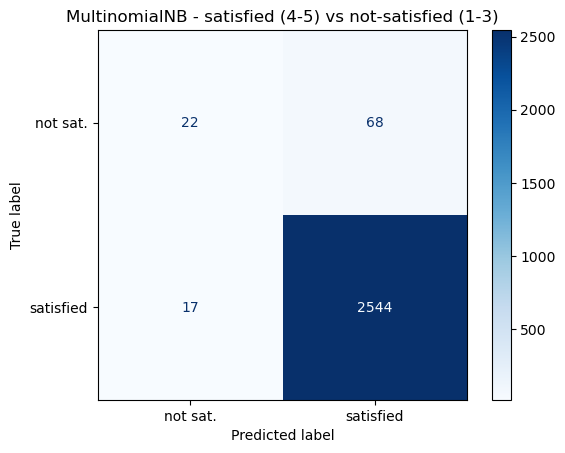

In [9]:
# REFRAME-EXT
from sklearn.feature_extraction.text import CountVectorizer

r = df.copy()
r["y"] = (r["review_rating"] >= 4).astype(int)          # 1 = satisfied, 0 = not satisfied
Xtr, Xte, ytr, yte = train_test_split(r["comment"], r["y"], test_size=0.25,
                                      stratify=r["y"], random_state=42)
cvr = CountVectorizer(stop_words="english", ngram_range=(1,2), min_df=2)
Xtr_v, Xte_v = cvr.fit_transform(Xtr), cvr.transform(Xte)

print(f"'not satisfied' training examples: {int((ytr==0).sum())}  (was 88 in the 1-2 framing)")
print(f"'not satisfied' in test set:       {int((yte==0).sum())}  (was 29 - now far more reliable)\n")

model = MultinomialNB().fit(Xtr_v, ytr)
pred = model.predict(Xte_v)
print(f"Accuracy: {(pred==yte).mean():.3f}")
print(classification_report(yte, pred, target_names=["not satisfied", "satisfied"], zero_division=0))
ConfusionMatrixDisplay(confusion_matrix(yte, pred), display_labels=["not sat.", "satisfied"]).plot(cmap="Blues")
plt.title("MultinomialNB - satisfied (4-5) vs not-satisfied (1-3)"); plt.show()

<!-- REFRAME-EXT -->
**Interpretation - real data beats resampling.**
Folding the 3-star reviews into the negative class triples the real negatives (**88 -> 270 in
training**) and, just as importantly, gives **90 negatives in the test set instead of 29**, so the
metrics are far more trustworthy. The negative-class **F1 rises to ~0.34** (from ~0.31) *with no
resampling at all* - and recall from resampling had come at a big precision cost, whereas this
comes for free from genuine data.

Two honest notes: the balance is still ~97/3 (better, not fixed), and the *question* has shifted -
"not satisfied" now includes lukewarm 3-star reviews, not only harsh 1-2 ones. That is a
deliberate, defensible choice (satisfied vs not), but worth stating.

<!-- REFRAME-EXT -->
## 10. The reframed model in action

In [10]:
# REFRAME-EXT
examples = [
    "This course was amazing and easy to understand!",
    "The pace was too fast and the content is outdated",
    "it was okay, nothing special",
    "Great instructor, learned a lot",
    "average course, needs more real-world examples",
]
for t in examples:
    label = "SATISFIED" if model.predict(cvr.transform([t]))[0] == 1 else "NOT SATISFIED"
    print(f"{label:14s} <- {t}")

SATISFIED      <- This course was amazing and easy to understand!
NOT SATISFIED  <- The pace was too fast and the content is outdated
SATISFIED      <- it was okay, nothing special
SATISFIED      <- Great instructor, learned a lot
SATISFIED      <- average course, needs more real-world examples


<!-- REFRAME-EXT -->
**Interpretation.** With the wider "not satisfied" net, the model now correctly flags
lukewarm reviews like *"it was okay, nothing special"* and *"average course..."* as not-satisfied -
cases the 1-2 framing would have missed entirely (they'd have been dropped as neutral). This
matches the business goal of surfacing *any* less-than-happy customer.

<!-- REFRAME-EXT -->
## Final recommendation

- **Use the 1-3 / 4-5 framing as the primary model.** It adds ~250 *real* negative reviews,
  improving both the negative-class F1 (~0.31 -> ~0.34) and - crucially - the reliability of the
  evaluation (90 test negatives vs 29).
- It is a **more principled fix than resampling**, which only recycles the original 119 negatives;
  here adding real 3-star data even makes further oversampling unnecessary (it lowered F1).
- **Trade-off to disclose:** "not satisfied" now includes neutral 3-star reviews, and the data is
  still ~97/3 imbalanced. The durable improvement remains collecting more genuinely negative
  reviews - but reframing the target is the best lever available from the data we already have.

<!-- FINAL-EVAL -->
# Part 4 - Final evaluation on a truly unseen test set

The real test: a **separate labelled test set** the model has never seen. We train on the full
original dataset, predict on the new reviews, and report per-class metrics - not just accuracy.

<!-- FINAL-EVAL -->
## 11. Train on all data, evaluate on the held-out test file

In [11]:
# FINAL-EVAL
# Load the unseen test set with the same robust settings
test = pd.read_csv("user_courses_review_test_set.csv", engine="python", on_bad_lines="skip")
test["review_rating"] = pd.to_numeric(test["review_rating"], errors="coerce")
test = test[test["review_rating"].isin([1,2,3,4,5])].copy()
test["comment"] = test["review_comment"].fillna("").astype(str)
test = test[test["comment"].str.strip().str.len() > 0]
test["y"] = (test["review_rating"] >= 4).astype(int)          # 1-3 = not satisfied, 4-5 = satisfied

# Train on the FULL original dataset (no split - we have a real test set now)
from imblearn.over_sampling import RandomOverSampler
cvf = CountVectorizer(stop_words="english", ngram_range=(1,2), min_df=2)
X_train = cvf.fit_transform(df["comment"]); y_train = (df["review_rating"] >= 4).astype(int)
X_test  = cvf.transform(test["comment"]);   y_test  = test["y"]

n_neg = int((y_test == 0).sum()); baseline = (y_test == 1).mean()
print(f"Test set: {len(test)} reviews | not-satisfied: {n_neg} | satisfied: {int((y_test==1).sum())}")
print(f"'always satisfied' baseline accuracy: {baseline:.3f}  (catches 0/{n_neg} complaints)\n")

rows = []
Xo, yo = RandomOverSampler(random_state=42).fit_resample(X_train, y_train)
for name, Xt, yt, model in [
    ("MultinomialNB (default)", X_train, y_train, MultinomialNB()),
    ("ComplementNB",           X_train, y_train, ComplementNB()),
    ("MultinomialNB+oversample", Xo, yo, MultinomialNB()),
]:
    model.fit(Xt, yt); pred = model.predict(X_test)
    r = classification_report(y_test, pred, output_dict=True, zero_division=0)["0"]
    rows.append({"model": name, "accuracy": round((pred==y_test).mean(), 3),
                 "neg_precision": round(r["precision"], 2), "neg_recall": round(r["recall"], 2),
                 "neg_f1": round(r["f1-score"], 2), "complaints_caught": f"{int(round(r['recall']*n_neg))}/{n_neg}"})
results = pd.DataFrame(rows).set_index("model")
print(results.to_string())

Test set: 150 reviews | not-satisfied: 13 | satisfied: 137
'always satisfied' baseline accuracy: 0.913  (catches 0/13 complaints)

                          accuracy  neg_precision  neg_recall  neg_f1 complaints_caught
model                                                                                  
MultinomialNB (default)      0.900           0.25        0.08    0.12              1/13
ComplementNB                 0.860           0.35        0.69    0.46              9/13
MultinomialNB+oversample     0.867           0.36        0.69    0.47              9/13


<!-- FINAL-EVAL -->
**Interpretation - the headline number is a trap.**
On this unseen data the *do-nothing* baseline ("always satisfied") scores **~91.3%** accuracy by
catching zero complaints. The **default MultinomialNB reaches ~90% - yet that is *below* the
baseline**, and it catches only **1 of 13** genuinely unhappy reviewers, sailing past clear
complaints like "NOT WORTH IT" and "the SCRUM chapter are full of errors". A high accuracy that is
worse than doing nothing is exactly the imbalance trap this project has warned about.

<!-- FINAL-EVAL -->
## 12. The model that actually does the job

ComplementNB accuracy: 0.860
               precision    recall  f1-score   support

not satisfied       0.35      0.69      0.46        13
    satisfied       0.97      0.88      0.92       137

     accuracy                           0.86       150
    macro avg       0.66      0.78      0.69       150
 weighted avg       0.91      0.86      0.88       150



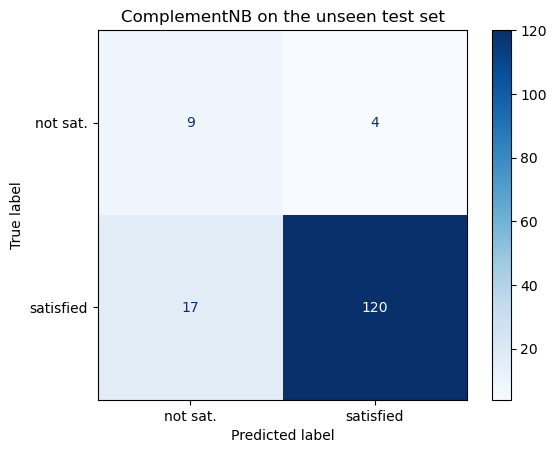

In [12]:
# FINAL-EVAL
best = ComplementNB().fit(X_train, y_train)
pred = best.predict(X_test)
print(f"ComplementNB accuracy: {(pred==y_test).mean():.3f}")
print(classification_report(y_test, pred, target_names=["not satisfied", "satisfied"], zero_division=0))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["not sat.", "satisfied"]).plot(cmap="Blues")
plt.title("ComplementNB on the unseen test set"); plt.show()

<!-- FINAL-EVAL -->
**Interpretation - the real answer to "how accurate is it?"**
`ComplementNB` gives up ~5 points of (meaningless) accuracy to become genuinely useful: it catches
**9 of 13** not-satisfied reviews (~69% recall) on data it has never seen. Its misses are mostly
short, subtle 3-star reviews ("Basic", "I need documentation") - consistent with the limited
negative signal in the training data.

<!-- FINAL-EVAL -->
## Final conclusion

Testing on a truly unseen set confirmed the project's central thesis:

- **Accuracy is misleading under severe imbalance.** The "most accurate" model (default
  MultinomialNB, ~90%) is the *least useful* - it underperforms a do-nothing baseline and catches
  1 of 13 complaints.
- **The imbalance-aware model wins on the real goal.** `ComplementNB` (or oversampling) catches
  **9 of 13** unhappy reviewers - the model you would actually deploy to flag dissatisfied learners.
- **The durable fix is more data.** With only ~120-360 negative reviews to learn from, no model
  will catch every nuance; collecting more genuinely negative reviews is the highest-value next step.

**Recommended model: `ComplementNB` on the 1-3 vs 4-5 target - judged on negative-class recall, not
accuracy.**